# Decisions: the lounge scorecard and the growth rule, calibrated

`src.model.scorecard.decide(features, flips)` turns each lounge's features (`features.ipynb`) into
PROTECT / HOLD / SHRINK from four weighted signals on **fixed scales**; `src.model.growth.classify(area)`
labels each growth area GROW / WATCH / SKIP. This notebook shows where the anchors and thresholds
come from, what they decide at medium levels, and how the calls move across the 81 level
combinations. **The user signed off the scorecard and the growth line on 2026-10-09:** keep Demand
and Capture as separate signals, rating at **half weight**, a call that flips in a third or more of the level
combinations is **low confidence** (9 of 27 then; 27 of 81 since affluence became the fourth level on
2026-10-10, `affluence.ipynb`), `UNSATURATED_PER_1K` = 50. Sections 5 and 6 keep the
alternatives that were weighed, as history; no model logic of its own except those alternatives,
computed inline for comparison. The calls are a shortlist to test, not decisions
(`docs/limitations.md`).

Data: `data/seed/v3/` via `src.data_v3.load_v3()`; assumptions in `data/scenarios/baseline.yaml`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import itertools
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src.config import load_baseline_assumptions
from src.data_v3 import LEVELS, load_v3
from src.features import lounges as L
from src.features.lounges import build
from src.market import premium_substitutes, women_15plus
from src.model import growth, scorecard
from src.model.scorecard import PROTECT_AT, SHRINK_AT, SIGNALS, score
from src.models import Levels

pd.set_option("display.width", 160)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.2, "grid.color": "#888", "axes.edgecolor": "#999", "font.size": 9})
BLUE, ORANGE, AQUA, YELLOW, GREY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9e9e9e", "#d64545"
ACTION_COLOR = {"PROTECT": AQUA, "HOLD": GREY, "SHRINK": ORANGE, "NOT SCORED": "#ddd",
                "GROW": AQUA, "WATCH": YELLOW, "SKIP": GREY}

A = load_baseline_assumptions(ROOT / "data/scenarios/baseline.yaml")
v3 = load_v3()
df = lambda rows: pd.DataFrame([r.model_dump() for r in rows])
feats, areas = build(v3, A)
F = df(feats).set_index("branch_id")
FLIPS = scorecard.level_flips(v3, A, Levels())   # per lounge: of 81 level combinations, how many change its call
D = df(scorecard.decide(feats, FLIPS)).set_index("branch_id")
AR = df(areas).set_index("area_id")
AD = df(growth.classify_all(areas)).set_index("area_id")
scored = F[~F.not_scored]
print(f"{len(F)} lounges ({F.not_scored.sum()} not scored), {len(AR)} growth areas at medium levels")

24 lounges (1 not scored), 580 growth areas at medium levels


## 1. The anchors

Four signals, each scored 0-1 on a fixed scale (clipped), then a weighted average: demand,
cannibalisation and capture weight 1, the rating gap 0.5. PROTECT at a composite ≥ 0.65, SHRINK
≤ 0.35, HOLD between. A thin premium market (fewer than 10 premium salons) scores capture 0.5; a
missing rating gap scores 0.5. **Low confidence**: within 0.05 of a line, a thin market or missing
gap, or a call that flips in a third (27+) of the 81 level combinations (section 4). Demand reads
**addressable women** (affluence-weighted by observed Dubai rents; neutral elsewhere). The airport lounge is NOT
SCORED (it serves travellers) and stays out of every count.

In [2]:
pd.DataFrame([{"signal": s.name, "field": s.field, "0 at": s.worst, "1 at": s.best, "weight": s.weight, "why": s.why} for s in SIGNALS]).style.hide(axis="index")

signal,field,0 at,1 at,weight,why
demand,addressable_women,0.000000,200000.000000,1.000000,"Affluence-weighted (Dubai rents; elsewhere a woman counts 1). Lounges range 23k-321k addressable women, median 107k (raw: 23k-272k, median 107k); 200k is where the four big Dubai lounges sit, weighted or not, and one lounge can't absorb more, so extra women stop counting."
cannibalisation,shared_share,1.000000,0.000000,1.000000,Already a 0-100% share: 0% means no sibling reaches this lounge's women. Abu Dhabi city lounges sit at 85-100%.
capture,capture,0.000000,0.150000,1.000000,"Median 6.5% over the scored lounges; 15% is about the best reliable lounge (al-taif-mall, 14%). Thin premium markets (under 10 premium salons) score 0.5: a share of a tiny pool is noise."
rating,rating_gap,-0.300000,0.300000,0.500000,"Gaps run -0.2 to +0.3, median -0.1: most lounges rate slightly below their premium substitutes; ±0.3 stars covers the whole range. Half weight: Google ratings come in 0.1 steps, so the gap takes only six values."


## 2. Signal distributions with the anchors

Each dot is a scored lounge at medium levels (orange: thin premium market). The shaded band runs
from the 0-anchor to the 1-anchor; values outside it clip.

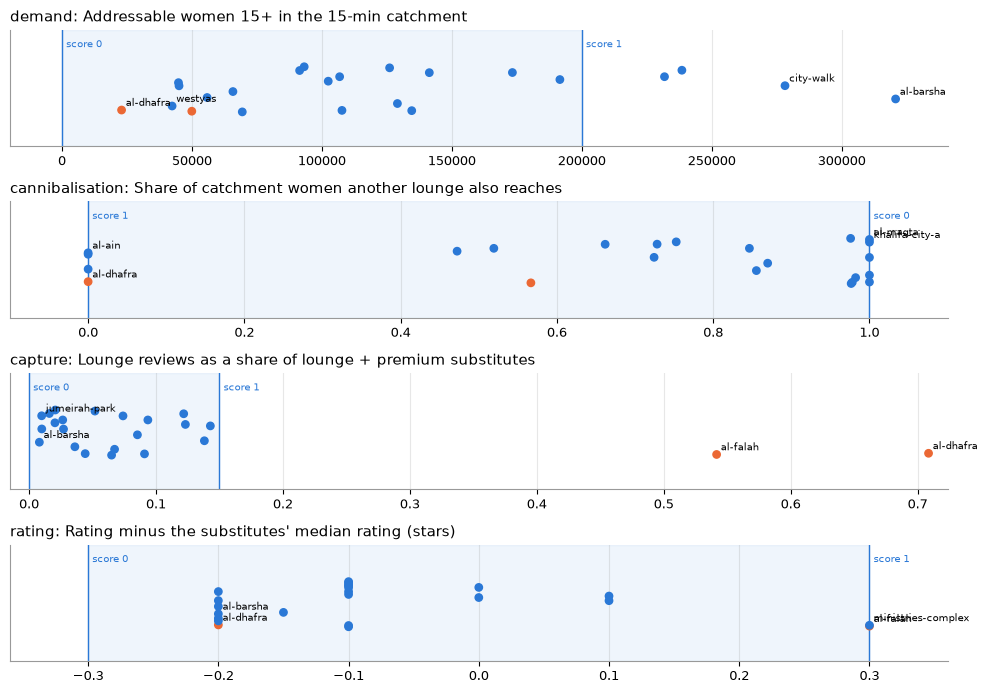

,addressable_women,shared_share,capture,rating_gap
count,23.000,23.000,23.000,23.000
mean,124468.227,0.692,0.110,-0.072
std,80781.557,0.363,0.170,0.147
min,22927.304,0.000,0.008,-0.200
25%,60804.427,0.543,0.024,-0.200
50%,106825.818,0.846,0.065,-0.100
75%,157313.133,0.980,0.108,-0.050
max,320730.567,1.000,0.709,0.300


In [3]:
fig, axes = plt.subplots(4, 1, figsize=(10, 7))
for ax, s in zip(axes, SIGNALS):
    x = scored[s.field].astype(float)
    lo, hi = sorted((s.worst, s.best))
    ax.axvspan(lo, hi, color=BLUE, alpha=0.07)
    for v, t in ((s.worst, "0"), (s.best, "1")):
        ax.axvline(v, color=BLUE, lw=1); ax.annotate(f"score {t}", (v, 0.85), xycoords=("data", "axes fraction"), fontsize=7, color=BLUE, xytext=(3, 0), textcoords="offset points")
    jit = np.random.default_rng(0).uniform(-0.25, 0.25, len(x))
    ax.scatter(x, jit, c=np.where(scored.thin_premium_market, ORANGE, BLUE), s=28, zorder=3)
    for b in x.nlargest(2).index.union(x.nsmallest(2).index):
        ax.annotate(b, (x[b], jit[list(x.index).index(b)]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    ax.set_ylim(-0.6, 0.6); ax.set_yticks([]); ax.set_title(f"{s.name}: {s.label}", loc="left")
    pad = (hi - lo) * 0.1
    ax.set_xlim(min(lo, x.min()) - pad, max(hi, x.max()) + pad)
plt.tight_layout(); plt.show()
scored[[s.field for s in SIGNALS]].describe().round(3)

## 3. Composite and action per lounge, medium levels

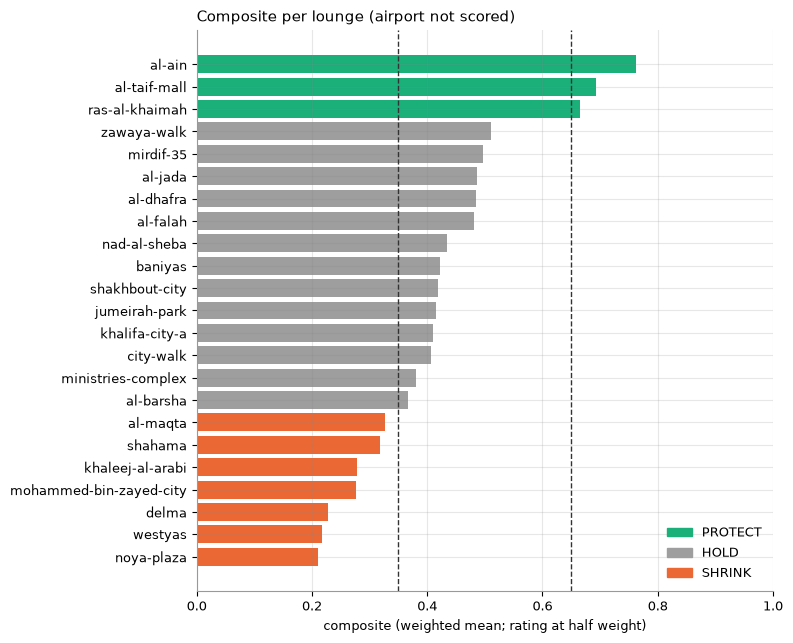

{'PROTECT': 3, 'HOLD': 13, 'SHRINK': 7} + 1 NOT SCORED


,emirate,action,confidence,composite,demand,cannibalisation,capture,rating,thin_premium_market,key_drivers
branch_id,,,,,,,,,,
zayed-international-airport,Abu Dhabi,NOT SCORED,low,0.000,NaN,NaN,NaN,NaN,False,[]
noya-plaza,Abu Dhabi,SHRINK,high,0.211,0.225,0.000,0.181,0.667,False,"[cannibalisation, capture]"
westyas,Abu Dhabi,SHRINK,high,0.218,0.212,0.018,0.449,0.167,False,"[cannibalisation, rating]"
delma,Abu Dhabi,SHRINK,high,0.227,0.466,0.024,0.138,0.333,False,"[cannibalisation, capture]"
mohammed-bin-zayed-city,Abu Dhabi,SHRINK,low,0.277,0.645,0.000,0.241,0.167,False,"[cannibalisation, rating]"
khaleej-al-arabi,Abu Dhabi,SHRINK,medium,0.277,0.347,0.023,0.434,0.333,False,"[cannibalisation, rating]"
shahama,Abu Dhabi,SHRINK,low,0.318,0.329,0.130,0.569,0.167,False,"[cannibalisation, rating]"
al-maqta,Abu Dhabi,SHRINK,low,0.327,0.630,0.000,0.346,0.333,False,"[cannibalisation, rating]"
al-barsha,Dubai,HOLD,low,0.366,1.000,0.145,0.054,0.167,False,"[demand, capture]"


In [4]:
t = D.join(F[["emirate", "thin_premium_market"]]).drop(columns=["rationale", "caveats"])
t = pd.concat([t, t.pop("scores").apply(pd.Series)], axis=1).sort_values("composite")
fig, ax = plt.subplots(figsize=(8, 6.5))
tb = t[t.action != "NOT SCORED"]
ax.barh(tb.index, tb.composite, color=[ACTION_COLOR[a] for a in tb.action])
for v in (SHRINK_AT, PROTECT_AT):
    ax.axvline(v, color="#333", lw=1, ls="--")
ax.set_xlabel("composite (weighted mean; rating at half weight)"); ax.set_xlim(0, 1)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=ACTION_COLOR[a]) for a in ("PROTECT", "HOLD", "SHRINK")],
          labels=["PROTECT", "HOLD", "SHRINK"], frameon=False, loc="lower right")
ax.set_title("Composite per lounge (airport not scored)", loc="left")
plt.tight_layout(); plt.show()
print(scorecard.counts(scorecard.decide(feats)), "+", (D.action == "NOT SCORED").sum(), "NOT SCORED")
t[["emirate", "action", "confidence", "composite", "demand", "cannibalisation", "capture", "rating", "thin_premium_market", "key_drivers"]].round(3)

**Reading it.** al-ain, al-taif-mall and ras-al-khaimah are PROTECT: catchments no other lounge
reaches and the best reliable capture (12-14%); ras-al-khaimah only just (0.66), so it is low
confidence. The seven SHRINKs are all Abu Dhabi city lounges with 87-100% of their women shared with
siblings and middling-to-low capture. SHRINK means "investigate", not "close": there is no revenue or
rent in the model. al-barsha (0.37) is the call most likely to be questioned: Dubai's biggest
catchment (demand scores 1), but it captures under 1% of a crowded premium market and shares 86% of
its women; it sits just above the SHRINK line and flips in 27 of 81 combinations. al-falah and
al-dhafra are thin markets: capture is neutral, confidence low.

## 4. How the actions move across all 81 level combinations

Travel time (10 / 15 / 20 min) x competitor coverage (50 / 60 / 70%) x worker-housing female share
(1 / 5.5 / 15%) x affluence elasticity (off 0 / 0.5 / strong 1). **Flips** = combinations (of 81)
whose action differs from the medium-levels action. A lounge with a third or more flips (27,
`scorecard.FLIP_LOW`) is low confidence; the confidence
column below includes that rule.

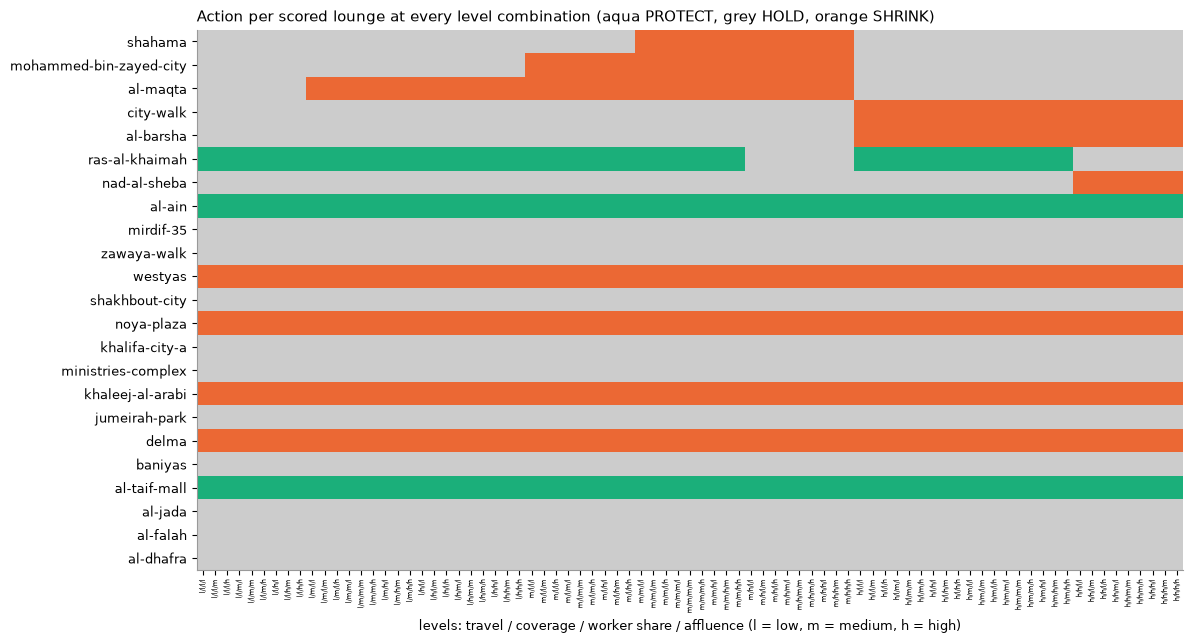

lounges that never flip: 16 of 23


,medium,confidence,flips,actions over 81
shahama,SHRINK,low,63,"{'HOLD': 63, 'SHRINK': 18}"
mohammed-bin-zayed-city,SHRINK,low,54,"{'HOLD': 54, 'SHRINK': 27}"
al-maqta,SHRINK,low,36,"{'HOLD': 36, 'SHRINK': 45}"
city-walk,HOLD,low,27,"{'HOLD': 54, 'SHRINK': 27}"
al-barsha,HOLD,low,27,"{'HOLD': 54, 'SHRINK': 27}"
ras-al-khaimah,PROTECT,low,18,"{'PROTECT': 63, 'HOLD': 18}"
nad-al-sheba,HOLD,medium,9,"{'HOLD': 72, 'SHRINK': 9}"
al-ain,PROTECT,high,0,{'PROTECT': 81}
mirdif-35,HOLD,high,0,{'HOLD': 81}
zawaya-walk,HOLD,high,0,{'HOLD': 81}


In [5]:
combos = list(itertools.product(LEVELS, repeat=4))
runs = {lv: build(v3, A, Levels(*lv)) for lv in combos}
ACT = pd.DataFrame({lv: {d.branch_id: d.action for d in scorecard.decide(runs[lv][0])} for lv in combos})
flips = ACT.ne(D.action, axis=0).sum(axis=1).rename("flips")
mix = ACT.apply(lambda r: dict(Counter(r)), axis=1).rename("actions over 81")
FL = pd.concat([D.action.rename("medium"), D.confidence, flips, mix], axis=1).sort_values("flips", ascending=False)
order = {"PROTECT": 2, "HOLD": 1, "SHRINK": 0, "NOT SCORED": np.nan}
fig, ax = plt.subplots(figsize=(12, 6.5))
M = ACT.loc[FL.index[FL.medium != "NOT SCORED"]].replace(order).astype(float)
ax.imshow(M, aspect="auto", cmap=plt.matplotlib.colors.ListedColormap([ORANGE, "#ccc", AQUA]), vmin=0, vmax=2)
ax.set_yticks(range(len(M)), M.index); ax.set_xticks(range(len(combos)), ["/".join(x[0] for x in lv) for lv in combos], rotation=90, fontsize=5)
ax.set_xlabel("levels: travel / coverage / worker share / affluence (l = low, m = medium, h = high)"); ax.grid(False)
ax.set_title("Action per scored lounge at every level combination (aqua PROTECT, grey HOLD, orange SHRINK)", loc="left")
plt.tight_layout(); plt.show()
print("lounges that never flip:", (flips[D.action != "NOT SCORED"] == 0).sum(), "of", (D.action != "NOT SCORED").sum())
FL[FL.medium != "NOT SCORED"]

In [6]:
print("One level moved at a time, the others at medium: lounges whose action changes")
for i, dim in enumerate(["travel", "coverage", "worker_share", "affluence"]):
    for lv in ("low", "high"):
        c = tuple(lv if j == i else "medium" for j in range(4))
        moved = ACT[c][ACT[c] != D.action]
        print(f"  {dim:>12} {lv:>4}: " + (", ".join(f"{b} -> {a}" for b, a in moved.items()) or "none"))

One level moved at a time, the others at medium: lounges whose action changes
        travel  low: mohammed-bin-zayed-city -> HOLD, shahama -> HOLD
        travel high: al-barsha -> SHRINK, al-maqta -> HOLD, city-walk -> SHRINK, mohammed-bin-zayed-city -> HOLD, shahama -> HOLD
      coverage  low: shahama -> HOLD
      coverage high: ras-al-khaimah -> HOLD
  worker_share  low: none
  worker_share high: none
     affluence  low: none
     affluence high: none


**Reading it.** Travel time drives the movement: at 10 min catchments shrink and capture rises
(mohammed-bin-zayed-city and shahama become HOLD); at 20 min al-barsha and city-walk drop to SHRINK
and three Abu Dhabi SHRINKs (al-maqta, mohammed-bin-zayed-city, shahama) rise to HOLD. Coverage moves
only shahama (low) and ras-al-khaimah (high); the worker-housing share alone moves nobody. 16 of 23
lounges never flip. The margin rule alone catches shahama, al-maqta and al-barsha (each within 0.05
of the SHRINK line) but not mohammed-bin-zayed-city (54 of 81, 0.07 away) or city-walk (27 of 81, 0.06
away). That is why flips set confidence: all five are low confidence. **Affluence moves nobody**:
only Dubai cells carry a rent, and the Dubai lounges whose demand it shifts sit above the 200k
anchor (`affluence.ipynb`), so every flip count is exactly three times its old count over 27 and
the low-confidence line, a third, lands on the same lounges.

## 5. Considered and rejected: one "estimated customers" signal for Demand and Capture

Capture's denominator is the reviews of competing premium salons, and busier catchments have more of
them. So the scorecard rewards a big catchment on Demand and penalises it on Capture. The
alternative weighed: one signal, **estimated customers** (capture x catchment women), in place of
the two, anchored the same way (0 at 0, 1 at about the best reliable lounge), giving three signals.
**Rejected 2026-10-09** (below). The table also compares the rating weights from section 6:
**full weight (draft)** against **half weight (adopted)**.

Spearman(catchment women, capture) = -0.74 over 23 scored lounges
best non-thin est_customers: {'al-ain': 12617.0, 'shakhbout-city': 12239.0, 'khalifa-city-a': 11140.0} ; median 4766
thin markets' est_customers (scored neutral, as capture is): {'al-dhafra': 16247.0, 'al-falah': 27054.0}


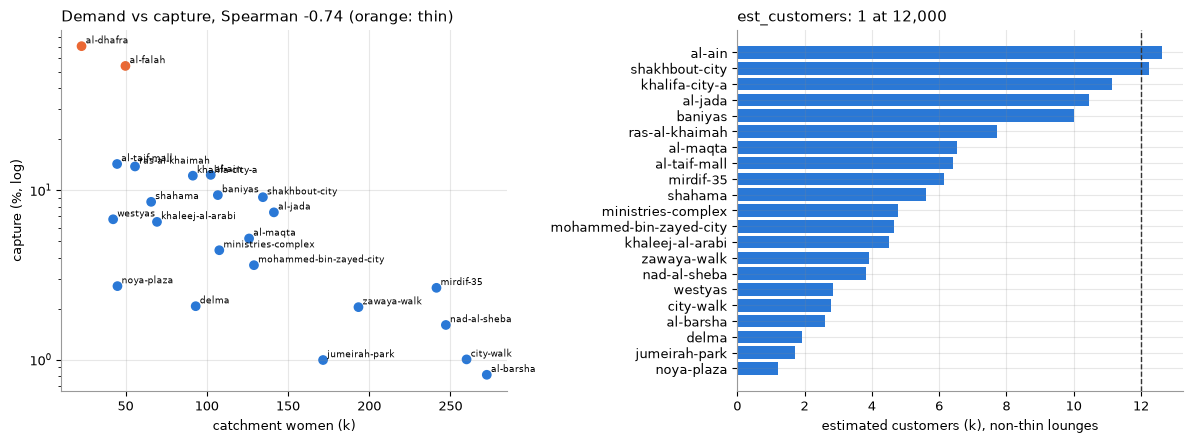

In [7]:
rho = scored.catchment_women.corr(scored.capture, method="spearman")
reliable = scored[~scored.thin_premium_market].est_customers.sort_values(ascending=False)
EST_BEST = 12_000   # proposal: ≈ the best reliable lounges (printed below)
print(f"Spearman(catchment women, capture) = {rho:+.2f} over {len(scored)} scored lounges")
print("best non-thin est_customers:", reliable.head(3).round(0).to_dict(), "; median", round(reliable.median()))
print("thin markets' est_customers (scored neutral, as capture is):", scored[scored.thin_premium_market].est_customers.round(0).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.scatter(scored.catchment_women / 1000, scored.capture * 100, c=np.where(scored.thin_premium_market, ORANGE, BLUE))
for b, r in scored.iterrows():
    ax.annotate(b, (r.catchment_women / 1000, r.capture * 100), fontsize=6.5, xytext=(3, 2), textcoords="offset points")
ax.set_yscale("log"); ax.set_xlabel("catchment women (k)"); ax.set_ylabel("capture (%, log)")
ax.set_title(f"Demand vs capture, Spearman {rho:+.2f} (orange: thin)", loc="left")
ax = axes[1]
ax.barh(reliable.index[::-1], reliable[::-1] / 1000, color=BLUE)
ax.axvline(EST_BEST / 1000, color="#333", ls="--", lw=1); ax.set_xlabel("estimated customers (k), non-thin lounges")
ax.set_title(f"est_customers: 1 at {EST_BEST:,}", loc="left")
plt.tight_layout(); plt.show()

In [8]:
SIG = {s.name: s for s in SIGNALS}
S = t.loc[t.action != "NOT SCORED", ["demand", "cannibalisation", "capture", "rating"]].copy()   # airport out
est = np.where(scored.thin_premium_market, 0.5, (scored.est_customers / EST_BEST).clip(0, 1))
S["est_customers"] = pd.Series(est, scored.index)
call = lambda c: np.where(c >= PROTECT_AT, "PROTECT", np.where(c <= SHRINK_AT, "SHRINK", "HOLD"))
ALT = pd.DataFrame({
    "full weight (draft)": S[["demand", "cannibalisation", "capture", "rating"]].mean(axis=1),
    "half weight (adopted)": (S.demand + S.cannibalisation + S.capture + 0.5 * S.rating) / 3.5,
    "est_customers (rejected)": S[["est_customers", "cannibalisation", "rating"]].mean(axis=1),
    "rating out (rejected)": S[["demand", "cannibalisation", "capture"]].mean(axis=1)}, index=S.index)
assert np.allclose(ALT["half weight (adopted)"], D.loc[S.index, "composite"], atol=1e-3), "adopted != scorecard"
CALLS = ALT.apply(call)
lists = pd.DataFrame({c: {a: ", ".join(sorted(CALLS.index[CALLS[c] == a])) or "-" for a in ("PROTECT", "SHRINK")}
                      | {"counts P/H/S": "/".join(str((CALLS[c] == a).sum()) for a in ("PROTECT", "HOLD", "SHRINK"))} for c in CALLS})
display(lists.style.set_properties(**{"white-space": "pre-wrap", "text-align": "left"}))
changed = CALLS[CALLS.nunique(axis=1) > 1]
print("Lounges whose call depends on the variant:")
pd.concat([ALT.loc[changed.index].round(3).add_suffix(" composite"), changed], axis=1)

,full weight (draft),half weight (adopted),est_customers (rejected),rating out (rejected)
PROTECT,"al-ain, al-taif-mall","al-ain, al-taif-mall, ras-al-khaimah","al-ain, al-taif-mall","al-ain, al-taif-mall, ras-al-khaimah"
SHRINK,"al-barsha, al-maqta, delma, khaleej-al-arabi, mohammed-bin-zayed-city, noya-plaza, shahama, westyas","al-maqta, delma, khaleej-al-arabi, mohammed-bin-zayed-city, noya-plaza, shahama, westyas","al-barsha, al-maqta, city-walk, delma, jumeirah-park, khaleej-al-arabi, mohammed-bin-zayed-city, nad-al-sheba, noya-plaza, shahama, westyas","al-maqta, delma, khaleej-al-arabi, ministries-complex, mohammed-bin-zayed-city, noya-plaza, shahama, westyas"
counts P/H/S,2/13/8,3/13/7,2/10/11,3/12/8


Lounges whose call depends on the variant:


,full weight (draft) composite,half weight (adopted) composite,est_customers (rejected) composite,rating out (rejected) composite,full weight (draft),half weight (adopted),est_customers (rejected),rating out (rejected)
branch_id,,,,,,,,
al-barsha,0.341,0.366,0.176,0.400,SHRINK,HOLD,SHRINK,HOLD
ministries-complex,0.458,0.381,0.466,0.278,HOLD,HOLD,HOLD,SHRINK
city-walk,0.377,0.407,0.225,0.448,HOLD,HOLD,SHRINK,HOLD
jumeirah-park,0.426,0.416,0.305,0.402,HOLD,HOLD,SHRINK,HOLD
nad-al-sheba,0.422,0.434,0.300,0.451,HOLD,HOLD,SHRINK,HOLD
ras-al-khaimah,0.613,0.664,0.631,0.733,HOLD,PROTECT,HOLD,PROTECT


**Reading it.** The correlation is strongly negative, so the scorecard does pay for a busy area
twice with opposite signs. With estimated customers, each lounge's market counts once, and the Dubai
lounges lose the crutch of a full demand score: city-walk, jumeirah-park, nad-al-sheba and al-barsha
become SHRINK (11 SHRINKs, against 8 under the full-weight draft and 7 under the adopted scorecard).
PROTECT loses ras-al-khaimah. In the 12,000 anchor, al-ain, shakhbout-city and khalifa-city-a
(11-13k) are the best non-thin lounges. **Rejected:** it is the more honest measure in principle, but
it would make four of the five Dubai lounges SHRINK on lifetime review counts alone, the weakest
input in the model (`docs/limitations.md`, 2).

## 6. The rating gap is coarse: half weight

Google ratings come in steps of 0.1, so the gap takes only a handful of values. And the premium filter
admits unpriced salons only at rating ≥ 4.3, which might pull the substitutes' median up.

distinct rating-gap values: [-0.2, -0.15, -0.1, 0.0, 0.1, 0.3] (6 values)


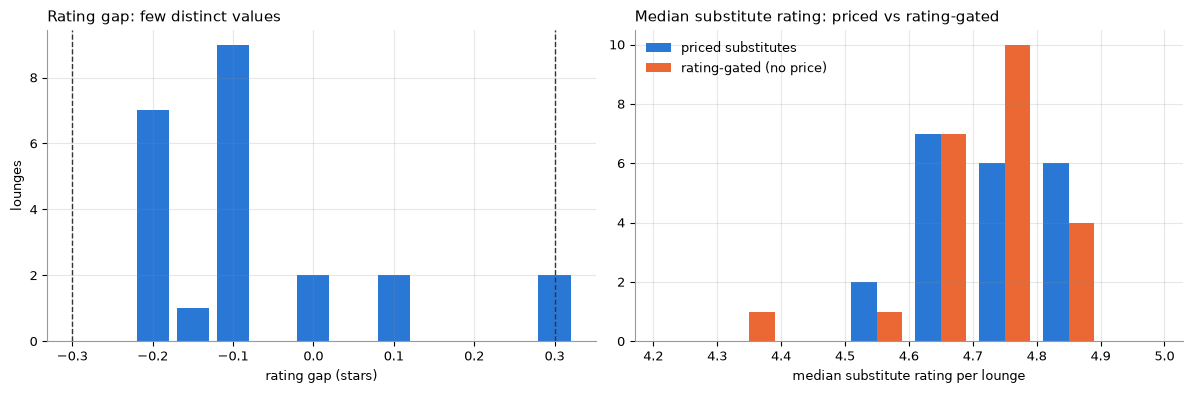

share of substitutes admitted by the rating gate: 45%; median of their per-lounge medians 4.70 vs priced 4.70


,rating,subs,by_price,by_rating_gate,median_priced,median_gated,median_all,gap
branch_id,,,,,,,,
al-barsha,4.6,63,28,35,4.80,4.80,4.80,-0.20
al-dhafra,4.5,3,0,3,NaN,4.70,4.70,-0.20
shahama,4.6,9,5,4,4.80,4.70,4.80,-0.20
mohammed-bin-zayed-city,4.4,18,7,11,4.50,4.70,4.60,-0.20
city-walk,4.6,50,24,26,4.80,4.80,4.80,-0.20
mirdif-35,4.5,23,18,5,4.70,4.60,4.70,-0.20
westyas,4.6,9,5,4,4.80,4.75,4.80,-0.20
ras-al-khaimah,4.5,8,6,2,4.65,4.80,4.65,-0.15
khaleej-al-arabi,4.6,29,15,14,4.70,4.70,4.70,-0.10


In [9]:
gap = scored.rating_gap.round(2)
print("distinct rating-gap values:", [float(x) for x in sorted(gap.dropna().unique())], f"({gap.nunique()} values)")
rows = []
for b in scored.index:
    cands = v3.candidates[(b, "medium")]
    subs = premium_substitutes(cands, len(cands), A.premium_min_rating, A.comparable_price_levels)[:int(F.loc[b, "substitutes_k"])]
    priced = [float(s["rating"]) for s in subs if s.get("price_level") and s.get("rating") is not None]
    gated = [float(s["rating"]) for s in subs if not s.get("price_level") and s.get("rating") is not None]
    rows.append({"branch_id": b, "rating": F.loc[b, "rating"], "subs": len(subs), "by_price": len(priced), "by_rating_gate": len(gated),
                 "median_priced": np.median(priced) if priced else np.nan, "median_gated": np.median(gated) if gated else np.nan,
                 "median_all": F.loc[b, "substitutes_median_rating"], "gap": gap[b]})
RG = pd.DataFrame(rows).set_index("branch_id")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = gap.value_counts().sort_index()
axes[0].bar(vc.index, vc.values, width=0.04, color=BLUE); axes[0].set_xlabel("rating gap (stars)"); axes[0].set_ylabel("lounges")
for v in (SIG["rating"].worst, SIG["rating"].best):
    axes[0].axvline(v, color="#333", ls="--", lw=1)
axes[0].set_title("Rating gap: few distinct values", loc="left")
axes[1].hist([RG.median_priced.dropna(), RG.median_gated.dropna()], bins=np.arange(4.2, 5.05, 0.1), label=["priced substitutes", "rating-gated (no price)"], color=[BLUE, ORANGE])
axes[1].set_xlabel("median substitute rating per lounge"); axes[1].legend(frameon=False)
axes[1].set_title("Median substitute rating: priced vs rating-gated", loc="left")
plt.tight_layout(); plt.show()
print(f"share of substitutes admitted by the rating gate: {RG.by_rating_gate.sum() / RG.subs.sum():.0%}; "
      f"median of their per-lounge medians {RG.median_gated.median():.2f} vs priced {RG.median_priced.median():.2f}")
RG.sort_values("gap").round(2)

**Reading it.** Six distinct values; at full weight a 0.1-star step moves the rating score by 1/6
and the composite by 0.04, enough to cross a threshold for a lounge near one. **The premium-filter
suspicion doesn't hold up:** 45% of substitutes enter through the rating gate, but their per-lounge
median rating (4.70) equals the priced substitutes' (4.70). The negative median gap is real: premium
salons near our lounges rate 4.6-4.8 and most lounges rate 4.5-4.6. Section 5's table shows the
remedies: **half weight (adopted)** keeps the signal but makes a 0.1-star step worth about 0.024 of
composite (against the full-weight draft, al-barsha moves to HOLD and ras-al-khaimah to PROTECT);
**rating out** (rejected) would also move ministries-complex, whose only strength is its +0.3 gap, to
SHRINK. Half weight, because the gap carries information (ministries-complex's 4.9 is real) but not at
full resolution.

## 7. Growth: where to draw the "unsaturated" line

Saturation = premium-salon reviews per 1,000 women 15+, recall-corrected, over the cells our search
covered. To compare like with like, the same measure is computed over each lounge's 15-min catchment
(the cells a lounge already operates in) with the same code as the areas (`lounges._area`).

lounge catchments, non-thin: min 88 (al-jada), median 220; thin: {'al-dhafra': 10.0, 'al-falah': 27.0}
growth areas with >= 5k women and data (54): median 5, 75th pct 54; under the line: 40


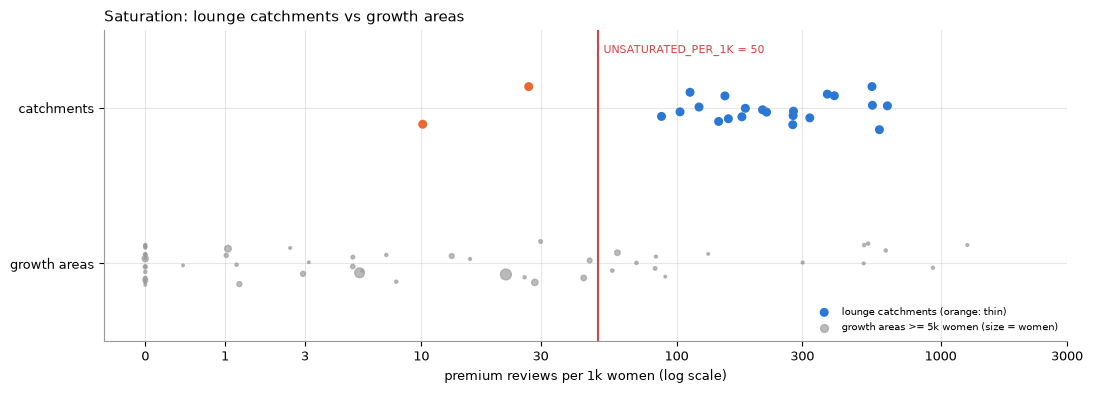

UNSATURATED_PER_1K why: Signed off by the user on 2026-10-09. Every lounge catchment with a real premium market (10+ premium salons) has 88+ premium reviews per 1k women (al-jada 88, median 220); the two thin ones are 10 and 27. Growth areas of 5k+ women have a median of 5 and a 75th percentile of 54. 50 is under the least crowded working catchment by a wide margin and splits the growth areas into the empty majority and the ones with an established premium scene.


In [10]:
p = L._prep(v3)
w = women_15plus(v3.cells, v3.emirates, A.worker_housing_female_share["medium"]).to_dict()
lats, lngs = np.array([lo.lat for lo in v3.lounges]), np.array([lo.lng for lo in v3.lounges])
CA = pd.DataFrame([L._area(lo.branch_id, lo.name, lo.emirate, [c for c in p["catch"]["medium"][lo.branch_id] if w[c] > 0],
                           w, w, v3.cells.rent_observed.to_dict(), p, A, v3.lounges, lats, lngs).model_dump() for lo in v3.lounges]).set_index("area_id")
CA = CA[~F.not_scored.reindex(CA.index)]   # the airport is not a lounge market
CA["thin"] = F.thin_premium_market
line = growth.UNSATURATED_PER_1K
G5 = AR[(AR.women >= growth.SKIP_UNDER_WOMEN) & AR.premium_reviews_per_1k.notna()]
working = CA[~CA.thin].premium_reviews_per_1k
print(f"lounge catchments, non-thin: min {working.min():.0f} ({working.idxmin()}), median {working.median():.0f}; "
      f"thin: {CA[CA.thin].premium_reviews_per_1k.round(0).to_dict()}")
print(f"growth areas with >= 5k women and data ({len(G5)}): median {G5.premium_reviews_per_1k.median():.0f}, "
      f"75th pct {G5.premium_reviews_per_1k.quantile(0.75):.0f}; under the line: {(G5.premium_reviews_per_1k < line).sum()}")
fig, ax = plt.subplots(figsize=(11, 4))
lg = lambda s: np.log10(s + 1)
ax.scatter(lg(CA.premium_reviews_per_1k), np.full(len(CA), 1) + np.random.default_rng(1).uniform(-0.15, 0.15, len(CA)),
           c=np.where(CA.thin, ORANGE, BLUE), s=30, label="lounge catchments (orange: thin)")
ax.scatter(lg(G5.premium_reviews_per_1k), np.random.default_rng(2).uniform(-0.15, 0.15, len(G5)), s=G5.women / 1500,
           color=GREY, alpha=0.7, label="growth areas >= 5k women (size = women)")
ax.axvline(lg(line), color=RED, lw=1.5); ax.annotate(f"UNSATURATED_PER_1K = {line:g}", (lg(line), 1.35), color=RED, fontsize=8, xytext=(4, 0), textcoords="offset points")
ticks = [0, 1, 3, 10, 30, 100, 300, 1000, 3000]
ax.set_xticks(lg(np.array(ticks)), ticks); ax.set_yticks([0, 1], ["growth areas", "catchments"]); ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("premium reviews per 1k women (log scale)"); ax.legend(frameon=False, loc="lower right", fontsize=7)
ax.set_title("Saturation: lounge catchments vs growth areas", loc="left")
plt.tight_layout(); plt.show()
print("UNSATURATED_PER_1K why:", growth.WHY["UNSATURATED_PER_1K"])

**50 premium reviews per 1k women** (signed off 2026-10-09). Every lounge that has a real premium market around it
operates at 88 or more (al-jada is the least crowded); only the two thin markets sit lower. Most growth
areas are near zero. 50 sits well below every working catchment, so "unsaturated" means clearly less
premium competition than any lounge faces today; areas between 50 and 88 (Al Jerf, 59) become WATCH.

## 8. Growth areas at medium levels

In [11]:
G = AR.join(AD[["action", "big_enough", "unsaturated", "rationale"]])
print(Counter(G.action))
cols = ["name", "emirate", "action", "women", "worker_share", "premium_salons", "premium_reviews_per_1k", "data_coverage", "nearest_lounge_id", "nearest_lounge_km"]
display(pd.crosstab(G.emirate, G.action, margins=True))
display(pd.crosstab(G.emirate, G.action, values=G.women, aggfunc="sum", margins=True).fillna(0).round(-2))
G[G.action != "SKIP"].sort_values(["action", "women"], key=lambda s: s.map({"GROW": 0, "WATCH": 1}) if s.name == "action" else -s)[cols].round(2)

Counter({'SKIP': 539, 'WATCH': 37, 'GROW': 4})


action,GROW,SKIP,WATCH,All
emirate,,,,
Abu Dhabi,0,223,15,238
Ajman,0,16,6,22
Dubai,0,109,9,118
Fujairah,0,66,0,66
Ras Al Khaimah,0,69,2,71
Sharjah,4,31,5,40
Umm Al Quwain,0,25,0,25
All,4,539,37,580


action,GROW,SKIP,WATCH,All
emirate,,,,
Abu Dhabi,0.0,342100.0,152000.0,494100.0
Ajman,0.0,55600.0,69000.0,124600.0
Dubai,0.0,183800.0,83400.0,267200.0
Fujairah,0.0,70200.0,0.0,70200.0
Ras Al Khaimah,0.0,76500.0,12500.0,89000.0
Sharjah,218300.0,68300.0,81100.0,367700.0
Umm Al Quwain,0.0,34400.0,0.0,34400.0
All,218300.0,830800.0,398100.0,1447200.0


,name,emirate,action,women,worker_share,premium_salons,premium_reviews_per_1k,data_coverage,nearest_lounge_id,nearest_lounge_km
area_id,,,,,,,,,,
sharjah-sharjah,Sharjah,Sharjah,GROW,90605.79,0.11,15.0,21.93,0.96,al-jada,13.26
al-dhaid-sharjah,Al Dhaid,Sharjah,GROW,73067.03,0.02,8.0,5.43,0.82,al-jada,43.78
khor-fakkan-sharjah,Khor Fakkan,Sharjah,GROW,31162.57,0.01,11.0,28.48,0.94,al-taif-mall,26.50
kalba-sharjah,Kalba,Sharjah,GROW,23464.26,0.00,6.0,44.09,0.98,al-taif-mall,11.10
al-madam-sharjah,Al Madam,Sharjah,WATCH,33678.55,0.01,1.0,1.05,0.42,mirdif-35,47.35
zayed-military-city-abu-dhabi,Zayed Military City,Abu Dhabi,WATCH,29181.10,0.02,0.0,0.00,0.23,al-falah,15.51
al-jerf-ajman,Al Jerf,Ajman,WATCH,23851.19,0.05,11.0,59.44,1.00,al-jada,13.20
al-awir-dubai,Al Awir,Dubai,WATCH,19386.74,0.00,1.0,1.27,0.86,mirdif-35,13.59
al-lesaily-dubai,Al Lesaily,Dubai,WATCH,18812.40,0.01,3.0,2.94,0.80,nad-al-sheba,27.08


In [12]:
from shapely.geometry import box, mapping
from scripts.spot_maps import points, shapes, show

cells = v3.cells
FILL = {"GROW": (27, 175, 122, 150), "WATCH": (237, 161, 0, 120), "SKIP": (158, 158, 158, 50)}
cellbox = lambda c, **p: {"type": "Feature", "geometry": mapping(box(c.west, c.south, c.east, c.north)), "properties": p}
feat = [cellbox(cells.loc[c], label=f"{r.name} ({r.emirate}): {r.action}, {r.women:,.0f} women", fill=list(FILL[r.action]))
        for r in G[G.women >= growth.SKIP_UNDER_WOMEN].itertuples() for c in r.cell_ids]
lounge_pts = [{"lat": r.lat, "lng": r.lng, "r": 600, "label": f"{b}: {D.action[b]}"} for b, r in F.iterrows()]
show([shapes(feat, fill="properties.fill", line=(80, 80, 80)), points(lounge_pts, (42, 120, 214))], 24.9, 55.2, zoom=7.6, height=560)

In [13]:
TRAVEL = {lv: Counter(d.action for d in growth.classify_all(runs[(lv, "medium", "medium", "medium")][1])) for lv in LEVELS}
GROWS = {lv: [d.area_id for d in growth.classify_all(runs[(lv, "medium", "medium", "medium")][1]) if d.action == "GROW"] for lv in LEVELS}
for lv in LEVELS:
    print(f"travel {lv}: {dict(TRAVEL[lv])}; GROW: {GROWS[lv]}")

travel low: {'GROW': 5, 'WATCH': 61, 'SKIP': 590}; GROW: ['sharjah-sharjah', 'al-dhaid-sharjah', 'kalba-sharjah', 'khor-fakkan-sharjah', 'al-shamkhah-abu-dhabi']
travel medium: {'GROW': 4, 'WATCH': 37, 'SKIP': 539}; GROW: ['sharjah-sharjah', 'al-dhaid-sharjah', 'khor-fakkan-sharjah', 'kalba-sharjah']
travel high: {'GROW': 3, 'WATCH': 18, 'SKIP': 505}; GROW: ['al-dhaid-sharjah', 'sharjah-sharjah', 'khor-fakkan-sharjah']


**Reading it.** At medium levels four areas are GROW, all in Sharjah emirate: Sharjah's outskirts (one
50-cell area, flagged in Task 3), Al Dhaid, Khor Fakkan and Kalba. **Al Awir** (Dubai, 19.4k women)
passes the 20k size line only through the affluence weighting, on rents for 38% of its women, so it
is capped at WATCH (`affluence.ipynb`). Al Madam and Zayed Military City are
big and look empty but under half their women sit in searched cells, so they cap at WATCH; Al Jerf
(Ajman) is just over the line. Longer drive times shrink the areas (more cells reached), so fewer
qualify.

## 9. Examples

**al-barsha** (HOLD at 0.37, low confidence: the call most likely to be questioned) and **al-jerf-ajman** (WATCH,
just over the saturation line). Lounge map: catchment cells (blue: shared, aqua: its own) and its
premium substitutes. Area map: its cells and its premium salons.

In [14]:
catch = v3.catchment[v3.catchment.level == "medium"]
others = set(catch[catch.branch_id != "al-barsha"].cell_id)
mine = sorted(set(catch[catch.branch_id == "al-barsha"].cell_id))
r, d = F.loc["al-barsha"], D.loc["al-barsha"]
display(Markdown(f"### al-barsha: {d.action} (composite {d.composite:.2f}, confidence {d.confidence})\n"
                 f"{r.catchment_women:,.0f} women, {r.shared_share:.0%} shared; {r.premium_pool} premium salons, k = {r.substitutes_k}, "
                 f"capture {r.capture:.1%}, rating gap {r.rating_gap:+.2f}; scores {d.scores}. Under the rejected est_customers signal: "
                 f"{CALLS.loc['al-barsha', 'est_customers (rejected)']} ({ALT.loc['al-barsha', 'est_customers (rejected)']:.2f}). "
                 f"Across 81 levels: {mix['al-barsha']}."))
cands = v3.candidates[("al-barsha", "medium")]
subs = premium_substitutes(cands, len(cands), A.premium_min_rating, A.comparable_price_levels)[:int(r.substitutes_k)]
display(show([shapes([cellbox(cells.loc[c], label=f"{cells.loc[c, 'name']}: {w[c]:,.0f} women, shared") for c in mine if c in others], fill=(42, 120, 214, 50)),
              shapes([cellbox(cells.loc[c], label=f"{cells.loc[c, 'name']}: {w[c]:,.0f} women, only al-barsha") for c in mine if c not in others],
                     fill=(27, 175, 122, 80), line=(27, 175, 122)),
              points([{"lat": s["lat"], "lng": s["lng"], "r": 40 + 3 * s["review_count"] ** 0.5, "label": f"{s['name']}: {s['review_count']} reviews, {s['rating']}★"} for s in subs], (235, 104, 52)),
              points([{"lat": r.lat, "lng": r.lng, "label": "al-barsha", "r": 300}], (20, 20, 20))], r.lat, r.lng, zoom=11))

a, ad = G.loc["al-jerf-ajman"], AD.loc["al-jerf-ajman"]
display(Markdown(f"### al-jerf-ajman: {ad.action}\n{ad.rationale} {a.women:,.0f} women in {a.cells} cells, {a.data_coverage:.0%} searched; "
                 f"{a.premium_salons:.0f} premium salons, {a.premium_reviews_per_1k:.0f} premium reviews per 1k women (line {line:g})."))
inside = lambda la, ln: any(cells.loc[c].south <= la < cells.loc[c].north and cells.loc[c].west <= ln < cells.loc[c].east for c in a.cell_ids)
sal = v3.salons[(v3.salons.excluded_reason == "") & ~v3.salons.is_bedashing.astype(bool)]
sal = sal[[inside(la, ln) for la, ln in zip(sal.lat, sal.lng)]].reset_index()
prem = premium_substitutes(sal.to_dict("records"), len(sal), A.premium_min_rating, A.comparable_price_levels)
display(show([shapes([cellbox(cells.loc[c], label=f"{w[c]:,.0f} women") for c in a.cell_ids], fill=(235, 104, 52, 50), line=(235, 104, 52)),
              points([{"lat": s["lat"], "lng": s["lng"], "r": 60 + 4 * s["review_count"] ** 0.5, "label": f"{s['name']}: {s['review_count']} reviews, {s['rating']}★"} for s in prem], (42, 120, 214))],
             a.lat, a.lng, zoom=12))
pd.DataFrame([{"name": s["name"], "reviews": s["review_count"], "rating": s["rating"], "price": s["price_level"] or "no price"} for s in prem])

### al-barsha: HOLD (composite 0.37, confidence low)
272,371 women, 86% shared; 228 premium salons, k = 63, capture 0.8%, rating gap -0.20; scores {'demand': 1.0, 'cannibalisation': 0.1447, 'capture': 0.0542, 'rating': 0.1667}. Under the rejected est_customers signal: SHRINK (0.18). Across 81 levels: {'HOLD': 54, 'SHRINK': 27}.

### al-jerf-ajman: WATCH
Big enough, but already served by premium salons. Nearest lounge: al-jada, 13.2 km in a straight line. 23,851 women in 5 cells, 100% searched; 11 premium salons, 59 premium reviews per 1k women (line 50).

,name,reviews,rating,price
0,Creation beauty lounge / branch,320,4.3,expensive
1,Level beauty center & spa ( salon ),203,3.5,expensive
2,صالون حريم السلطان | Hareem Al Sultan Salon,202,4.3,no price
3,Oro Beauty Centre,74,4.5,no price
4,Salon Ahlam Al Omer,70,4.5,no price
5,N Garden Beauty Lounge,38,4.3,no price
6,Rit Spa Center,35,4.7,no price
7,wasel haircutting saloon since 2018,20,4.4,no price
8,صالون الاناقة للتجميل,14,4.7,no price
9,Ezza Beauty Salon,14,4.4,no price


## Summary of the final scorecard

Everything below is computed from the code as signed off on 2026-10-09: the anchors, rating at half
weight, flips in confidence, est_customers rejected, `UNSATURATED_PER_1K` = 50. Treat the calls as a
shortlist to test with the business; `docs/limitations.md` ranks what could change them.

In [15]:
names = lambda a: ", ".join(D.index[D.action == a])
top = G[G.action != "SKIP"].sort_values("women", ascending=False).head(10)
low = D[(D.action != "NOT SCORED") & (D.confidence == "low")]
col = lambda c: lists[c]
out = ["**Anchors** (0 → 1, weight): " + "; ".join(f"{s.name} `{s.field}` {s.worst:g} → {s.best:g} ({s.weight:g})" for s in SIGNALS)
       + f". PROTECT ≥ {PROTECT_AT}, SHRINK ≤ {SHRINK_AT}; thin market → capture 0.5; low confidence within 0.05 of a line, "
       f"on a missing input, or at {scorecard.FLIP_LOW}+ flips of {scorecard.COMBOS}.",
       f"**Actions at medium levels** {scorecard.counts(scorecard.decide(feats))} + {(D.action == 'NOT SCORED').sum()} NOT SCORED (airport).",
       f"- PROTECT: {names('PROTECT')}", f"- HOLD: {names('HOLD')}", f"- SHRINK (investigate): {names('SHRINK')}",
       f"**Low confidence: {len(low)} of {(D.action != 'NOT SCORED').sum()}**: " + ", ".join(low.index),
       "**Flips across 81 level combinations** (combos differing from medium): "
       + ", ".join(f"{b} {n}" for b, n in flips[(flips > 0) & (D.action != 'NOT SCORED')].sort_values(ascending=False).items())
       + f"; {(flips[D.action != 'NOT SCORED'] == 0).sum()} lounges never flip.",
       f"**Rating weight** (P/H/S): full weight (draft) {col('full weight (draft)')['counts P/H/S']}; "
       f"half weight (adopted) {col('half weight (adopted)')['counts P/H/S']}; rating out (rejected) {col('rating out (rejected)')['counts P/H/S']}.",
       f"**est_customers (rejected)**: Spearman(women, capture) = {rho:+.2f}; replacing demand and capture would give "
       f"P/H/S {col('est_customers (rejected)')['counts P/H/S']}, SHRINK {col('est_customers (rejected)')['SHRINK']}.",
       f"**UNSATURATED_PER_1K = {line:g}**: non-thin lounge catchments ≥ {working.min():.0f} (median {working.median():.0f}); growth areas ≥ 5k women median {G5.premium_reviews_per_1k.median():.0f}.",
       f"**Growth areas** {dict(Counter(G.action))}. Top by women (GROW/WATCH):"]
out += [f"- {r.name} ({r.emirate}): {r.women:,.0f} women, {r.action}" for r in top.itertuples()]
display(Markdown("\n\n".join(out)))

**Anchors** (0 → 1, weight): demand `addressable_women` 0 → 200000 (1); cannibalisation `shared_share` 1 → 0 (1); capture `capture` 0 → 0.15 (1); rating `rating_gap` -0.3 → 0.3 (0.5). PROTECT ≥ 0.65, SHRINK ≤ 0.35; thin market → capture 0.5; low confidence within 0.05 of a line, on a missing input, or at 27+ flips of 81.

**Actions at medium levels** {'PROTECT': 3, 'HOLD': 13, 'SHRINK': 7} + 1 NOT SCORED (airport).

- PROTECT: al-ain, al-taif-mall, ras-al-khaimah

- HOLD: al-barsha, al-dhafra, al-falah, al-jada, baniyas, city-walk, jumeirah-park, khalifa-city-a, ministries-complex, mirdif-35, nad-al-sheba, shakhbout-city, zawaya-walk

- SHRINK (investigate): al-maqta, delma, khaleej-al-arabi, mohammed-bin-zayed-city, noya-plaza, shahama, westyas

**Low confidence: 10 of 23**: al-barsha, al-dhafra, al-falah, al-maqta, al-taif-mall, city-walk, ministries-complex, mohammed-bin-zayed-city, ras-al-khaimah, shahama

**Flips across 81 level combinations** (combos differing from medium): shahama 63, mohammed-bin-zayed-city 54, al-maqta 36, al-barsha 27, city-walk 27, ras-al-khaimah 18, nad-al-sheba 9; 16 lounges never flip.

**Rating weight** (P/H/S): full weight (draft) 2/13/8; half weight (adopted) 3/13/7; rating out (rejected) 3/12/8.

**est_customers (rejected)**: Spearman(women, capture) = -0.74; replacing demand and capture would give P/H/S 2/10/11, SHRINK al-barsha, al-maqta, city-walk, delma, jumeirah-park, khaleej-al-arabi, mohammed-bin-zayed-city, nad-al-sheba, noya-plaza, shahama, westyas.

**UNSATURATED_PER_1K = 50**: non-thin lounge catchments ≥ 88 (median 220); growth areas ≥ 5k women median 5.

**Growth areas** {'GROW': 4, 'WATCH': 37, 'SKIP': 539}. Top by women (GROW/WATCH):

- Sharjah (Sharjah): 90,606 women, GROW

- Al Dhaid (Sharjah): 73,067 women, GROW

- Al Madam (Sharjah): 33,679 women, WATCH

- Khor Fakkan (Sharjah): 31,163 women, GROW

- Zayed Military City (Abu Dhabi): 29,181 women, WATCH

- Al Jerf (Ajman): 23,851 women, WATCH

- Kalba (Sharjah): 23,464 women, GROW

- Al Awir (Dubai): 19,387 women, WATCH

- Al Lesaily (Dubai): 18,812 women, WATCH

- Al Ruways Industrial City (Abu Dhabi): 18,099 women, WATCH